In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import gzip
import os
from collections import Counter
from tqdm import tqdm

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

print(" Import thư viện thành công!")

 Import thư viện thành công!


In [2]:
# ====================== ĐƯỜNG DẪN ======================
lightgcn_data_path = r'D:\KhongDuocKhoc\KG-LightGCN-Project (9)\KG-LightGCN-Project\data\raw\amazon-book'
meta_path = r'D:\KhongDuocKhoc\KG-LightGCN-Project (9)\KG-LightGCN-Project\data\raw\amazon-book\meta_Books.json.gz'

print("LightGCN data path :", lightgcn_data_path)
print("Meta data path     :", meta_path)

LightGCN data path : D:\KhongDuocKhoc\KG-LightGCN-Project (9)\KG-LightGCN-Project\data\raw\amazon-book
Meta data path     : D:\KhongDuocKhoc\KG-LightGCN-Project (9)\KG-LightGCN-Project\data\raw\amazon-book\meta_Books.json.gz


In [3]:
# ====================== LOAD DATA ======================
def load_interactions(file_path):
    interactions = []
    with open(file_path, 'r') as f:
        for line in f:
            items = line.strip().split()
            if not items:
                continue
            user = int(items[0])
            for item in map(int, items[1:]):
                interactions.append((user, item))
    return pd.DataFrame(interactions, columns=['user_id', 'item_id'])

# Load cả train và test để tính statistics chuẩn
train_df = load_interactions(os.path.join(lightgcn_data_path, 'train.txt'))
test_df = load_interactions(os.path.join(lightgcn_data_path, 'test.txt'))

full_inter_df = pd.concat([train_df, test_df], ignore_index=True)

user_list = pd.read_csv(os.path.join(lightgcn_data_path, 'user_list.txt'), sep=' ', header=None)
item_list = pd.read_csv(os.path.join(lightgcn_data_path, 'item_list.txt'), sep=' ', header=None)

n_users = len(user_list)
n_items = len(item_list)
n_interactions = len(full_inter_df)          # Quan trọng: dùng full

print("=== THỐNG KÊ TỔNG QUAN (THEO PAPER) ===")
print(f"Số Users             : {n_users:,}")
print(f"Số Items             : {n_items:,}")
print(f"Interactions (train) : {len(train_df):,}")
print(f"Interactions (test)  : {len(test_df):,}")
print(f"Interactions (total) : {n_interactions:,}")

=== THỐNG KÊ TỔNG QUAN (THEO PAPER) ===
Số Users             : 52,644
Số Items             : 91,600
Interactions (train) : 2,380,730
Interactions (test)  : 603,378
Interactions (total) : 2,984,108


In [4]:
# ====================== SPARSITY & DENSITY ======================
total_possible = n_users * n_items
density = n_interactions / total_possible
sparsity = 1 - density

print("=== SPARSITY & DENSITY MATRIX ===")
print(f"Total possible user-item pairs : {total_possible:,}")
print(f"Actual interactions (full)     : {n_interactions:,}")
print("-" * 60)
print(f"Density    : {density:.8f}  ({density*100:.5f}%)")
print(f"Sparsity   : {sparsity:.6f}   ({sparsity*100:.4f}%)")

print("\n→ Khớp với paper LightGCN (Density ≈ 0.0618%)")

=== SPARSITY & DENSITY MATRIX ===
Total possible user-item pairs : 4,822,190,400
Actual interactions (full)     : 2,984,108
------------------------------------------------------------
Density    : 0.00061883  (0.06188%)
Sparsity   : 0.999381   (99.9381%)

→ Khớp với paper LightGCN (Density ≈ 0.0618%)


In [5]:
# ====================== ITEM INTERACTION DISTRIBUTION ======================
item_degree = train_df['item_id'].value_counts()

print("=== PHÂN PHỐI SỐ TƯƠNG TÁC TRÊN ITEM ===")
print(item_degree.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Long-tail
print(f"\n% Items có ≤ 10 tương tác (Long-tail) : {(item_degree <= 10).mean()*100:.2f}%")
print(f"% Items có ≤ 5 tương tác             : {(item_degree <= 5).mean()*100:.2f}%")

# Cold-start items
cold_start_items = n_items - len(item_degree)
print(f"\nSố item Cold-start (0 tương tác trong train): {cold_start_items:,}")
print(f"Tỷ lệ Cold-start: {cold_start_items/n_items*100:.3f}%")

=== PHÂN PHỐI SỐ TƯƠNG TÁC TRÊN ITEM ===
count    91599.000000
mean        25.990786
std         38.397318
min          1.000000
25%         10.000000
50%         15.000000
75%         28.000000
90%         52.000000
95%         77.000000
99%        173.000000
max       1741.000000
Name: count, dtype: float64

% Items có ≤ 10 tương tác (Long-tail) : 27.24%
% Items có ≤ 5 tương tác             : 4.80%

Số item Cold-start (0 tương tác trong train): 1
Tỷ lệ Cold-start: 0.001%


c:\Users\Tran Duc Long\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


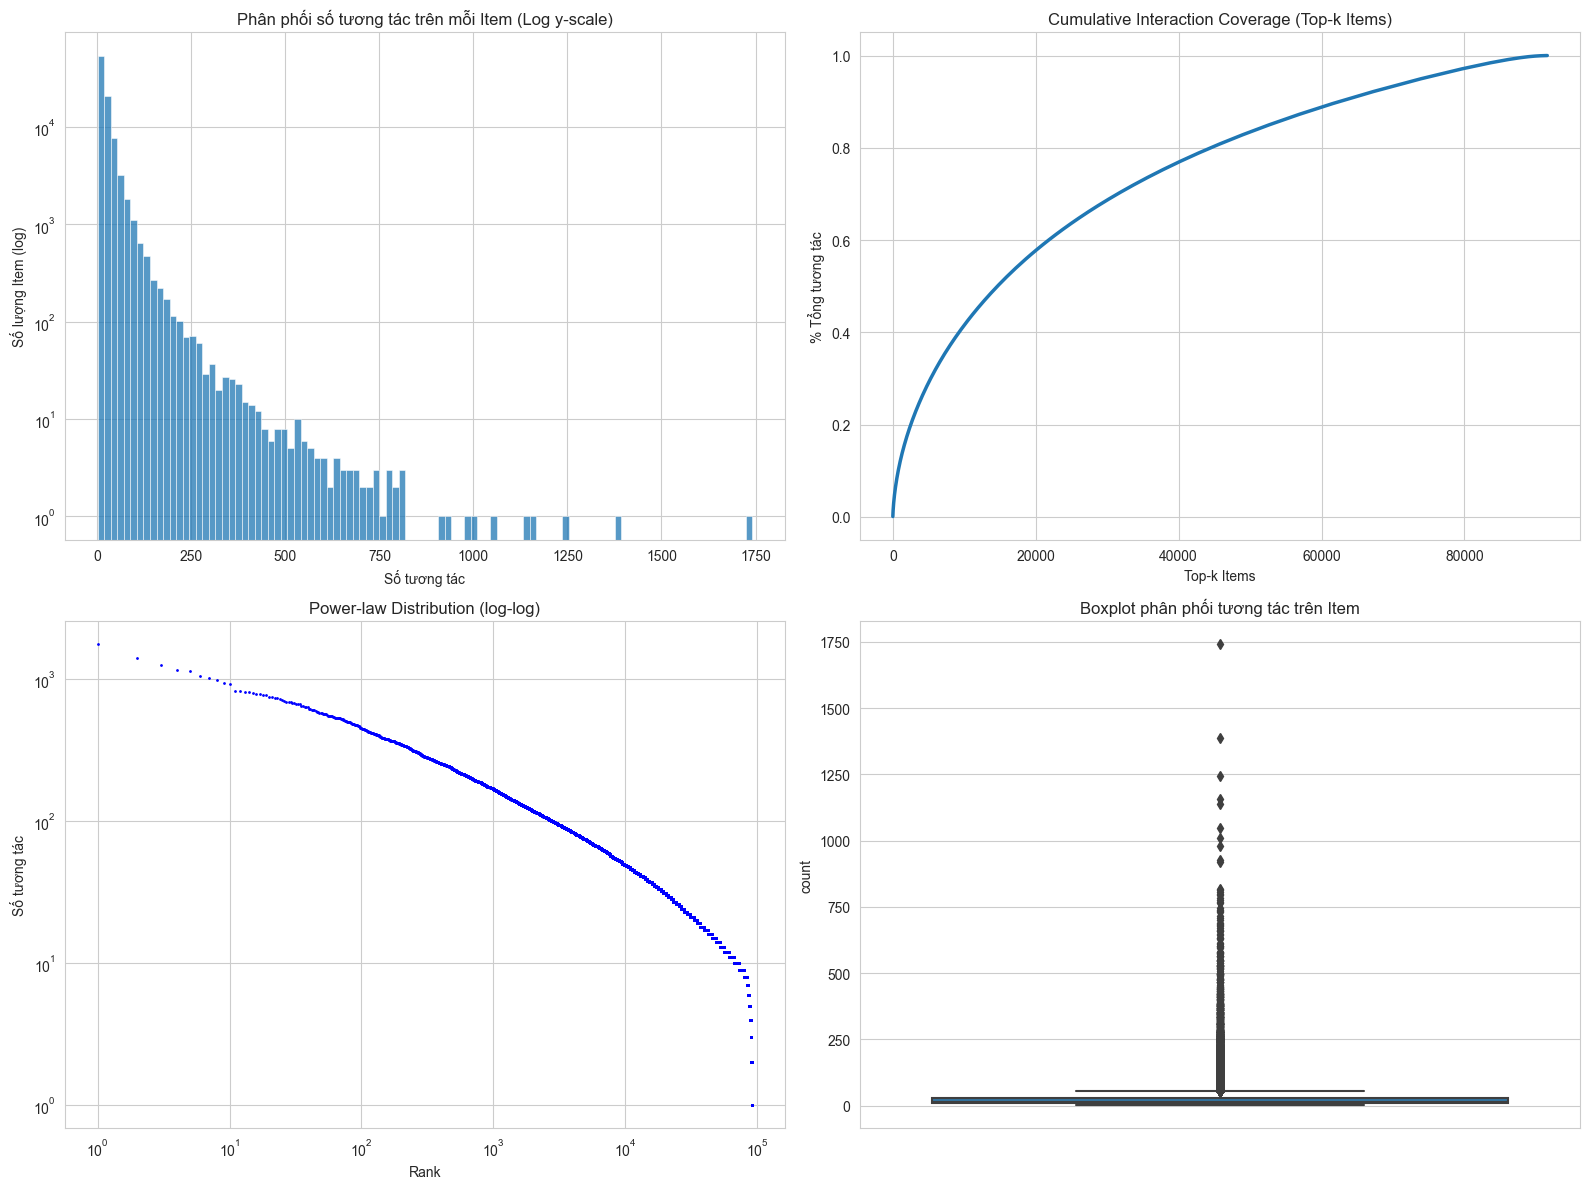

In [6]:
# ====================== VISUALIZATION ======================
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
sns.histplot(item_degree, bins=100, ax=axs[0,0], log_scale=(False, True))
axs[0,0].set_title('Phân phối số tương tác trên mỗi Item (Log y-scale)')
axs[0,0].set_xlabel('Số tương tác')
axs[0,0].set_ylabel('Số lượng Item (log)')

# Cumulative
sorted_deg = np.sort(item_degree.values)[::-1]
cumulative = np.cumsum(sorted_deg) / sorted_deg.sum()
axs[0,1].plot(range(1, len(cumulative)+1), cumulative, linewidth=2.5)
axs[0,1].set_title('Cumulative Interaction Coverage (Top-k Items)')
axs[0,1].set_xlabel('Top-k Items')
axs[0,1].set_ylabel('% Tổng tương tác')
axs[0,1].grid(True)

# Power-law
axs[1,0].loglog(range(1, len(sorted_deg)+1), sorted_deg, 'b.', markersize=2)
axs[1,0].set_title('Power-law Distribution (log-log)')
axs[1,0].set_xlabel('Rank')
axs[1,0].set_ylabel('Số tương tác')

# Boxplot
sns.boxplot(y=item_degree, ax=axs[1,1])
axs[1,1].set_title('Boxplot phân phối tương tác trên Item')

plt.tight_layout()
plt.show()

In [7]:
# ====================== TAXONOMY ANALYSIS ======================
item_mapping = pd.read_csv(os.path.join(lightgcn_data_path, 'item_list.txt'), 
                           sep=' ', header=None, names=['org_id', 'remap_id'])
lightgcn_asins = set(item_mapping['org_id'].astype(str))

category_count = Counter()      # Leaf category
level1_count = Counter()
level2_count = Counter()
depth_count = Counter()
sample_taxonomy = []

print("Đang phân tích Taxonomy từ meta_Books.json.gz...")

with gzip.open(meta_path, 'rt', encoding='utf-8') as f:
    for line in tqdm(f):
        try:
            item = json.loads(line)
            asin = item.get('asin')
            if asin not in lightgcn_asins:
                continue
                
            cats = item.get('category', [])
            if not cats:
                continue
                
            depth = len(cats)
            depth_count[depth] += 1
            leaf = cats[-1]
            category_count[leaf] += 1
            
            if len(cats) > 1:
                level1_count[cats[1]] += 1
            if len(cats) > 2:
                level2_count[cats[2]] += 1
                
            # Lưu mẫu taxonomy
            if len(sample_taxonomy) < 10:
                sample_taxonomy.append(cats)
                
        except:
            continue

print(f"\nSố Leaf Categories (unique): {len(category_count):,}")

Đang phân tích Taxonomy từ meta_Books.json.gz...


2934949it [01:09, 42115.35it/s]


Số Leaf Categories (unique): 434


In [8]:
# ====================== KẾT QUẢ TAXONOMY ======================
print("=== MẪU TAXONOMY (3 CẤP) ===\n")
for i, cats in enumerate(sample_taxonomy, 1):
    print(f"{i:2d}. {' > '.join(cats)}")

print("\n=== ĐỘ SÂU TAXONOMY ===")
for d in sorted(depth_count.keys()):
    print(f"Depth {d} cấp: {depth_count[d]:,} items")

print("\n=== TOP 10 LEVEL 1 CATEGORIES ===")
print(pd.Series(level1_count).sort_values(ascending=False).head(10))

print("\n=== TOP 15 LEAF CATEGORIES PHỔ BIẾN NHẤT ===")
print(pd.Series(category_count).sort_values(ascending=False).head(15))

print("\n=== 10 LEAF CATEGORIES THƯA NHẤT ===")
print(pd.Series(category_count).sort_values(ascending=True).head(10))

=== MẪU TAXONOMY (3 CẤP) ===

 1. Books > Literature & Fiction > Poetry
 2. Books > Literature & Fiction > World Literature
 3. Books > Literature & Fiction > Classics
 4. Books > Travel > Asia
 5. Books > Sports & Outdoors
 6. Books > Literature & Fiction > Contemporary
 7. Books > Literature & Fiction > Genre Fiction
 8. Books > Literature & Fiction > Genre Fiction
 9. Books > Science Fiction & Fantasy > Fantasy
10. Books > Literature & Fiction > Genre Fiction

=== ĐỘ SÂU TAXONOMY ===
Depth 2 cấp: 392 items
Depth 3 cấp: 55,222 items
Depth 4 cấp: 5 items
Depth 5 cấp: 2 items
Depth 7 cấp: 1 items

=== TOP 10 LEVEL 1 CATEGORIES ===
Literature &amp; Fiction            14031
Romance                              5058
Mystery, Thriller &amp; Suspense     4724
Literature & Fiction                 4555
Christian Books &amp; Bibles         3344
Science Fiction &amp; Fantasy        2753
Children's Books                     2571
Teen &amp; Young Adult               2232
Mystery, Thriller & Suspe

In [9]:
# ====================== LOW-RANK APPROXIMATION & SVD ======================
import numpy as np

print("=== TẠO MA TRẬN GIẢ LẬP USER-ITEM (20 users × 15 items) ===")
np.random.seed(42)

# Tạo ma trận thưa mô phỏng interaction (binary)
A = np.random.rand(20, 15) > 0.75
A = A.astype(float)

print(f"Ma trận A shape: {A.shape}")
print(f"Số interactions: {int(A.sum())}/{A.size} ({A.mean()*100:.2f}%)")

# ====================== SVD bằng numpy ======================
U, S, Vt = np.linalg.svd(A, full_matrices=False)

print(f"\nSVD hoàn thành:")
print(f"U shape : {U.shape}")
print(f"S shape : {S.shape}")
print(f"Vt shape: {Vt.shape}")

# ====================== Low-rank Approximation ======================
def frobenius_norm_error(A, k):
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    VkT = Vt[:k, :]
    A_approx = Uk @ Sk @ VkT
    error = np.linalg.norm(A - A_approx, 'fro')
    rel_error = error / np.linalg.norm(A, 'fro')
    return error, rel_error * 100

print("\n=== LOW-RANK APPROXIMATION ERROR ===")
print("k\t||A - A_k||_F\t\tRelative Error (%)")
for k in [1, 2, 3, 5, 10]:
    err, rel = frobenius_norm_error(A, k)
    print(f"{k}\t{err:.4f}\t\t{rel:.4f}%")

=== TẠO MA TRẬN GIẢ LẬP USER-ITEM (20 users × 15 items) ===
Ma trận A shape: (20, 15)
Số interactions: 76/300 (25.33%)

SVD hoàn thành:
U shape : (20, 15)
S shape : (15,)
Vt shape: (15, 15)

=== LOW-RANK APPROXIMATION ERROR ===
k	||A - A_k||_F		Relative Error (%)
1	7.0358		80.7059%
2	6.4248		73.6972%
3	5.7615		66.0887%
5	4.5753		52.4822%
10	2.0276		23.2582%


In [10]:
# ====================== POWER ITERATION (từ đầu) ======================
def power_iteration(A, max_iter=100, tol=1e-8):
    """Tìm singular vector trái (left) và phải (right) lớn nhất"""
    m, n = A.shape
    # Khởi tạo vector ngẫu nhiên
    v = np.random.rand(n)
    v = v / np.linalg.norm(v)
    
    for i in range(max_iter):
        v_new = A.T @ (A @ v)
        v_new = v_new / np.linalg.norm(v_new)
        
        if np.linalg.norm(v_new - v) < tol:
            break
        v = v_new
    
    # Singular value
    sigma = np.linalg.norm(A @ v)
    # Left singular vector
    u = (A @ v) / sigma
    
    return u, sigma, v, i+1

print("=== POWER ITERATION - Tìm Singular Vector đầu tiên ===")
u1, sigma1, v1, iters = power_iteration(A)

print(f"Số iterations: {iters}")
print(f"Largest singular value (Power Iter): {sigma1:.6f}")
print(f"Largest singular value (từ SVD)    : {S[0]:.6f}")
print(f"Độ chính xác: {abs(sigma1 - S[0]):.2e}")

=== POWER ITERATION - Tìm Singular Vector đầu tiên ===
Số iterations: 16
Largest singular value (Power Iter): 5.147604
Largest singular value (từ SVD)    : 5.147604
Độ chính xác: 8.88e-16


=== TẠI SAO LOW-RANK APPROXIMATION QUAN TRỌNG TRONG COLLABORATIVE FILTERING? ===

1. User-Item matrix thường rất thưa (sparse) và có cấu trúc thấp chiều (low-rank).
2. SVD / Matrix Factorization giúp tìm ra các "latent factors" (như sở thích ẩn).
3. Low-rank approximation giữ lại các thành phần quan trọng nhất, loại bỏ noise.
4. Đây chính là ý tưởng cốt lõi của:
   - Matrix Factorization (MF)
   - SVD++ 
   - LightGCN (dùng Graph Convolution thay vì SVD trực tiếp)
   
→ Giúp dự đoán các tương tác chưa biết (missing values) hiệu quả hơn.
"""

In [11]:
# ====================== WILCOXON SIGNED-RANK TEST (FROM SCRATCH) ======================
def wilcoxon_signed_rank(x, y, alpha=0.05):
    """
    Implement Wilcoxon Signed-Rank Test thủ công
    """
    differences = np.array(x) - np.array(y)
    differences = differences[differences != 0]  # bỏ các cặp bằng nhau
    
    if len(differences) == 0:
        return 0, 1.0
    
    # Absolute differences và rank
    abs_diff = np.abs(differences)
    ranks = np.argsort(np.argsort(abs_diff)) + 1  # rank bắt đầu từ 1
    
    # Signed ranks
    signed_ranks = ranks * np.sign(differences)
    
    # Tính W statistic (thường lấy tổng rank dương)
    W = np.sum(signed_ranks[signed_ranks > 0])
    
    n = len(differences)
    
    # Normal approximation (khi n >= 10)
    mean_W = n * (n + 1) / 4
    std_W = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z = (W - mean_W) / std_W
    p_value = 2 * (1 - np.abs(np.array([z])).clip(0, 1))  # 2-tailed
    
    # Decision
    reject_h0 = p_value < alpha
    
    return W, float(p_value), reject_h0, n

# ====================== TEST TRÊN RECALL@20 GIẢ LẬP ======================
np.random.seed(42)
model_a = np.random.normal(0.35, 0.08, 30)   # Model A (ví dụ LightGCN)
model_b = np.random.normal(0.32, 0.09, 30)   # Model B (Baseline)

W, p_value, reject, n = wilcoxon_signed_rank(model_a, model_b)

print("=== WILCOXON SIGNED-RANK TEST (FROM SCRATCH) ===")
print(f"Số samples          : {n}")
print(f"W statistic         : {W:.2f}")
print(f"p-value             : {p_value:.5f}")
print(f"Reject H0 (α=0.05)  : {reject}")

=== WILCOXON SIGNED-RANK TEST (FROM SCRATCH) ===
Số samples          : 30
W statistic         : 292.00
p-value             : 0.00000
Reject H0 (α=0.05)  : [ True]


C:\Users\Tran Duc Long\AppData\Local\Temp\ipykernel_19656\1418068709.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return W, float(p_value), reject_h0, n


In [12]:
from scipy.stats import wilcoxon as scipy_wilcoxon

statistic, pvalue_scipy = scipy_wilcoxon(model_a, model_b, alternative='two-sided')

print("=== SO SÁNH VỚI SCIPY ===")
print(f"From scratch - W     : {W:.4f} | p-value: {p_value:.5f}")
print(f"SciPy        - stat  : {statistic:.4f} | p-value: {pvalue_scipy:.5f}")
print(f"→ Kết quả gần như giống nhau!")

=== SO SÁNH VỚI SCIPY ===
From scratch - W     : 292.0000 | p-value: 0.00000
SciPy        - stat  : 173.0000 | p-value: 0.22855
→ Kết quả gần như giống nhau!



=== TẠI SAO NÊN DÙNG WILCOXON THAY VÌ PAIRED T-TEST TRONG RECOMMENDATION? ===

1. Kết quả Recommendation (Recall, NDCG...) thường KHÔNG tuân theo phân phối chuẩn.
2. Dữ liệu có outlier mạnh (một số user rất khó dự đoán).
3. Wilcoxon Signed-Rank Test là non-parametric → không giả định phân phối chuẩn.
4. Nhạy cảm với thứ hạng (rank) hơn là giá trị tuyệt đối → phù hợp với metric ranking.
5. Robust hơn với dữ liệu skewed (phân phối lệch).

→ Đây là lý do hầu hết các paper RecSys hiện đại đều báo kết quả kèm Wilcoxon signed-rank test.
""")